In [12]:
# Cell 1
# WO2 — Rainfall modality: doubled-angle investigation
# Parts A and B of wo2_rainfall-modality.md
# Monthly columns: basin06.pre_mm_s01 .. pre_mm_s12 (smallint); same in basin08 (integer)

%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scripts.shared import db_utils

conn = db_utils.db_connect()

ROOT = Path(db_utils.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'cdop'

In [13]:
# Cell 2
# Helper: compute standard and doubled-angle concentration from monthly precip array.
# r: array-like of 12 monthly values (mm); returns (R_std, phi_std, R_dbl, phi_dbl)
# R_std high → single wet season
# R_dbl high (and R_std low) → two wet seasons
# Both low → aseasonal or arid (distinguish by pre_mm_syr)

def circular_stats(r):
    r = np.asarray(r, dtype=float)
    total = r.sum()
    if total == 0:
        return np.nan, np.nan, np.nan, np.nan
    months = np.arange(12)
    theta_std = 2 * np.pi * months / 12
    theta_dbl = 2 * np.pi * months / 6   # doubled: months 6 apart map to same angle
    x_s = np.sum(r * np.cos(theta_std)); y_s = np.sum(r * np.sin(theta_std))
    x_d = np.sum(r * np.cos(theta_dbl)); y_d = np.sum(r * np.sin(theta_dbl))
    R_std = np.sqrt(x_s**2 + y_s**2) / total
    phi_std = (np.degrees(np.arctan2(y_s, x_s)) % 360) / 30  # peak month 0–11
    R_dbl = np.sqrt(x_d**2 + y_d**2) / total
    phi_dbl = (np.degrees(np.arctan2(y_d, x_d)) % 360) / 60  # first peak month 0–5
    return R_std, phi_std, R_dbl, phi_dbl

In [14]:
# Cell 3
# Pull monthly profiles for probe cities.
# basin08 is verbatim BasinATLAS — derived scalars (pre_concentration etc.) don't exist there;
# seasonality.py computes them on-the-fly from pre_mm_monthly. We do the same in Cell 4.

probe_sql = """
SELECT
    c.city,
    c.country,
    ST_Y(c.geom) AS lat,
    ST_X(c.geom) AS lon,
    b.hybas_id,
    b.pre_mm_syr,
    b.pre_mm_s01, b.pre_mm_s02, b.pre_mm_s03, b.pre_mm_s04,
    b.pre_mm_s05, b.pre_mm_s06, b.pre_mm_s07, b.pre_mm_s08,
    b.pre_mm_s09, b.pre_mm_s10, b.pre_mm_s11, b.pre_mm_s12
FROM gaz.wh_cities c
JOIN basin08 b ON b.id = c.basin_id
WHERE c.city IN ('Mombasa', 'Augsburg', 'Salzburg', 'George Town', 'Split', 'Timbuktu')
ORDER BY c.city
"""
probes = pd.read_sql(probe_sql, conn)
print(probes.to_string())

          city   country        lat         lon      hybas_id  pre_mm_syr  pre_mm_s01  pre_mm_s02  pre_mm_s03  pre_mm_s04  pre_mm_s05  pre_mm_s06  pre_mm_s07  pre_mm_s08  pre_mm_s09  pre_mm_s10  pre_mm_s11  pre_mm_s12
0     Augsburg   Germany  48.371667   10.898333  2.080471e+09         990          55          55          61          73         106         124         125         119          82          62          63          65
1  George Town  Malaysia   5.414500  100.329200  4.080021e+09        2563          86          92         144         206         247         188         210         243         334         404         269         140
2      Mombasa     Kenya  -4.050000   39.666667  1.080009e+09        1101          27          18          59         163         235          95          74          74          73         110         112          61
3     Salzburg   Austria  47.797200   13.047680  2.080486e+09        1248          77          68          81          91       

In [15]:
# Cell 4
# Compute circular stats for probe cities.
# R_std is what seasonality.py calls pre_concentration; phi_std is pre_peak_month direction.
# seas_phase_offset requires temperature too — deferred to Cell 11 for Mombasa specifically.

month_cols = [f'pre_mm_s{i:02d}' for i in range(1, 13)]

results = []
for _, row in probes.iterrows():
    r = row[month_cols].values
    R_std, phi_std, R_dbl, phi_dbl = circular_stats(r)
    results.append({
        'city': row['city'],
        'country': row['country'],
        'pre_mm_syr': row['pre_mm_syr'],
        'R_std': round(R_std, 3) if not np.isnan(R_std) else np.nan,
        'phi_std_peak_month': round(phi_std, 1) if not np.isnan(phi_std) else np.nan,
        'argmax_month': int(np.argmax(r)),
        'R_dbl': round(R_dbl, 3) if not np.isnan(R_dbl) else np.nan,
        'phi_dbl_first_peak': round(phi_dbl, 1) if not np.isnan(phi_dbl) else np.nan,
    })

print(pd.DataFrame(results).to_string())

          city   country  pre_mm_syr  R_std  phi_std_peak_month  argmax_month  R_dbl  phi_dbl_first_peak
0     Augsburg   Germany         990  0.212                 5.7             6  0.080                 5.6
1  George Town  Malaysia        2563  0.225                 7.6             9  0.187                 3.1
2      Mombasa     Kenya        1101  0.215                 4.8             4  0.341                 3.7
3     Salzburg   Austria        1248  0.193                 5.8             6  0.096                 5.6
4        Split   Croatia         901  0.191                10.8            10  0.111                 4.0
5     Timbuktu      Mali         172  0.865                 6.7             7  0.575                 0.7


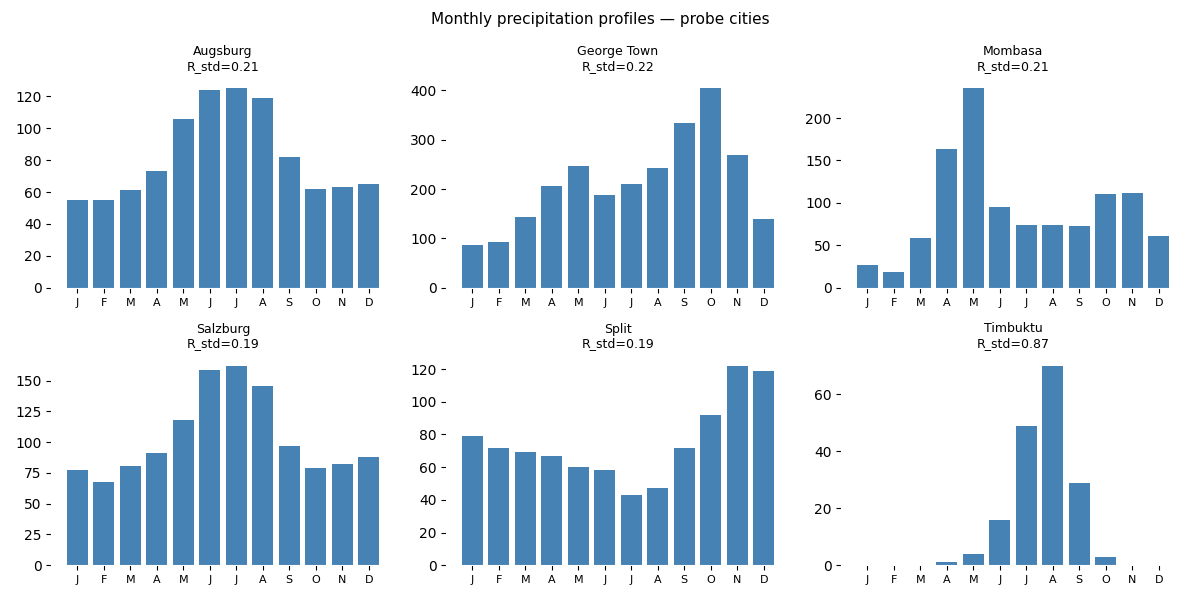

In [17]:
# Cell 5
# Plot monthly profiles for the probe cities.
# Mombasa → two peaks (Apr-May, Oct-Nov); Augsburg/Salzburg → gentle even distribution;
# George Town → weakly bimodal; Split → Mediterranean winter peak; Timbuktu → single summer monsoon

month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

print("drawing probe profiles...")
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=False)
fig.patch.set_facecolor('white')

for ax, (_, row) in zip(axes.flat, probes.iterrows()):
    vals = row[month_cols].values.astype(float)
    R_std_val, _, _, _ = circular_stats(vals)
    ax.set_facecolor('white')
    ax.bar(range(12), vals, color='steelblue')
    ax.set_xticks(range(12))
    ax.set_xticklabels(month_labels, fontsize=8, color='black')
    ax.tick_params(colors='black')
    ax.set_title(f"{row['city']}\nR_std={R_std_val:.2f}", fontsize=9, color='black')

fig.suptitle('Monthly precipitation profiles — probe cities', color='black', fontsize=11)
plt.tight_layout()
outpath = OUT / 'wo2_probe_profiles.png'
fig.savefig(outpath, facecolor='white')
plt.close(fig)
from IPython.display import Image as IPImage
display(IPImage(str(outpath)))

In [18]:
# Cell 6
# Scale to all L06 basins: compute R_std and R_dbl for every basin.
# ~16k rows; should run in seconds.

bulk_sql = """
SELECT hybas_id, pre_mm_syr,
       pre_mm_s01, pre_mm_s02, pre_mm_s03, pre_mm_s04,
       pre_mm_s05, pre_mm_s06, pre_mm_s07, pre_mm_s08,
       pre_mm_s09, pre_mm_s10, pre_mm_s11, pre_mm_s12
FROM basin06
"""
df06 = pd.read_sql(bulk_sql, conn)
print(f"{len(df06):,} L06 basins loaded")

M = df06[month_cols].values.astype(float)       # shape (N, 12)
total = M.sum(axis=1, keepdims=True)             # (N, 1)

months = np.arange(12)
theta_std = 2 * np.pi * months / 12
theta_dbl = 2 * np.pi * months / 6

with np.errstate(invalid='ignore', divide='ignore'):
    xs = (M * np.cos(theta_std)).sum(axis=1)
    ys = (M * np.sin(theta_std)).sum(axis=1)
    xd = (M * np.cos(theta_dbl)).sum(axis=1)
    yd = (M * np.sin(theta_dbl)).sum(axis=1)
    t = total.squeeze()
    df06['R_std'] = np.where(t > 0, np.sqrt(xs**2 + ys**2) / t, np.nan)
    df06['R_dbl'] = np.where(t > 0, np.sqrt(xd**2 + yd**2) / t, np.nan)

print(df06[['R_std', 'R_dbl']].describe().to_string())

16,397 L06 basins loaded
              R_std         R_dbl
count  1.633800e+04  1.633800e+04
mean   4.119391e-01  1.824109e-01
std    2.301504e-01  1.594132e-01
min    6.123234e-17  5.551115e-17
25%    2.226832e-01  7.213325e-02
50%    3.881740e-01  1.293713e-01
75%    5.960030e-01  2.406536e-01
max    1.000000e+00  1.000000e+00


In [19]:
# Cell 7
# Classify basins into four regimes using thresholds (to be reviewed).
# Initial thresholds: R_std >= 0.4 → single; R_std < 0.4 & R_dbl >= 0.3 → bimodal;
# both low + pre_mm_syr < 100 → arid; else aseasonal.
# Adjust after looking at the Cell 6 distributions.

THRESH_STD   = 0.4   # single wet season
THRESH_DBL   = 0.3   # bimodal detection
THRESH_ARID  = 100   # mm/yr — below this = arid rather than aseasonal

def classify(row):
    if pd.isna(row['R_std']):
        return 'no_data'
    if row['R_std'] >= THRESH_STD:
        return 'single'
    if row['R_dbl'] >= THRESH_DBL:
        return 'bimodal'
    if row['pre_mm_syr'] < THRESH_ARID:
        return 'arid'
    return 'aseasonal'

df06['regime'] = df06.apply(classify, axis=1)
counts = df06['regime'].value_counts()
print(counts)
print(f"\nBimodal fraction: {counts.get('bimodal', 0) / len(df06):.1%}")

regime
single       7923
aseasonal    7885
bimodal       386
arid          144
no_data        59
Name: count, dtype: int64

Bimodal fraction: 2.4%


In [20]:
# Cell 7b
# How many WH Cities fall in bimodal L06 basins?
# This is the sandbox exposure count — sandbox Similarity uses L06 globally.
# Fixes to the rainfall regime measure will affect both sandbox (L06 global)
# and cdop_pilot (L08 corpus-restricted).
# wh_cities.basin_id links to L08, so we spatial-join to get L06 basin for each city.

print("querying WH Cities → L06 basin assignment (spatial join)...")
city_l06_sql = """
SELECT c.id, c.city, c.country,
       b6.hybas_id AS hybas_id_l06
FROM gaz.wh_cities c
JOIN basin06 b6 ON ST_Contains(b6.geom, c.geom)
"""
city_l06 = pd.read_sql(city_l06_sql, conn)
print(f"{len(city_l06)} of 258 WH Cities matched to an L06 basin")

city_l06 = city_l06.merge(
    df06[['hybas_id', 'regime']], left_on='hybas_id_l06', right_on='hybas_id', how='left'
)
regime_counts = city_l06['regime'].value_counts()
print("\nWH Cities by L06 rainfall regime:")
print(regime_counts.to_string())
print(f"\nBimodal cities: {regime_counts.get('bimodal', 0)} of {len(city_l06)}")

bimodal_cities = city_l06[city_l06['regime'] == 'bimodal'][['city', 'country']].sort_values('country')
print("\nBimodal WH Cities (L06):")
print(bimodal_cities.to_string())

querying WH Cities → L06 basin assignment (spatial join)...
254 of 258 WH Cities matched to an L06 basin

WH Cities by L06 rainfall regime:
regime
aseasonal    158
single        91
bimodal        3
arid           2

Bimodal cities: 3 of 254

Bimodal WH Cities (L06):
              city   country
123           Lamu     Kenya
140        Mombasa     Kenya
249  Zanzibar City  Tanzania


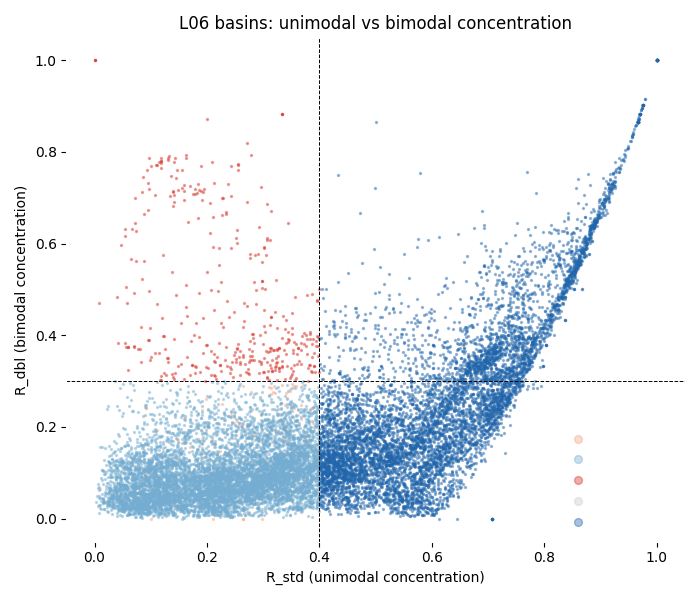

In [21]:
# Cell 8
# Scatter R_std vs R_dbl, coloured by regime. Visualise the separation.

colours = {'single': '#2166ac', 'bimodal': '#d73027', 'arid': '#f4a582', 'aseasonal': '#74add1', 'no_data': '#cccccc'}

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
for regime, grp in df06.groupby('regime'):
    ax.scatter(grp['R_std'], grp['R_dbl'], s=2, alpha=0.4,
               color=colours.get(regime, '#999'), label=regime)
ax.axvline(THRESH_STD, color='black', lw=0.7, ls='--')
ax.axhline(THRESH_DBL, color='black', lw=0.7, ls='--')
ax.set_xlabel('R_std (unimodal concentration)', color='black')
ax.set_ylabel('R_dbl (bimodal concentration)', color='black')
ax.tick_params(colors='black')
ax.legend(markerscale=4, frameon=False)
ax.set_title('L06 basins: unimodal vs bimodal concentration', color='black')
plt.tight_layout()
outpath = OUT / 'wo2_regime_scatter.png'
fig.savefig(outpath, facecolor='white'); plt.close(fig)
from IPython.display import Image as IPImage
display(IPImage(str(outpath)))

In [22]:
# Cell 9
# Where are the bimodal basins? Pull centroids for map (Cell 10).
# Expect East Africa, Indonesia, coastal Brazil, Sahel margin, parts of monsoon Asia.

import geopandas as gpd

bimodal_ids = df06.loc[df06['regime'] == 'bimodal', 'hybas_id'].tolist()
print(f"{len(bimodal_ids):,} bimodal basins")

id_list = ','.join(str(i) for i in bimodal_ids)
centroid_sql = f"""
SELECT hybas_id, ST_X(ST_Centroid(geom)) AS lon, ST_Y(ST_Centroid(geom)) AS lat
FROM basin06
WHERE hybas_id IN ({id_list})
"""
centroids = pd.read_sql(centroid_sql, conn)
print(centroids.head().to_string())

386 bimodal basins
       hybas_id        lon        lat
0  4.060761e+09  79.481546  30.489613
1  4.060799e+09  81.965382  29.674561
2  4.060770e+09  83.626083  29.965160
3  4.060787e+09  84.545662  29.300024
4  4.060779e+09  83.787521  29.691538


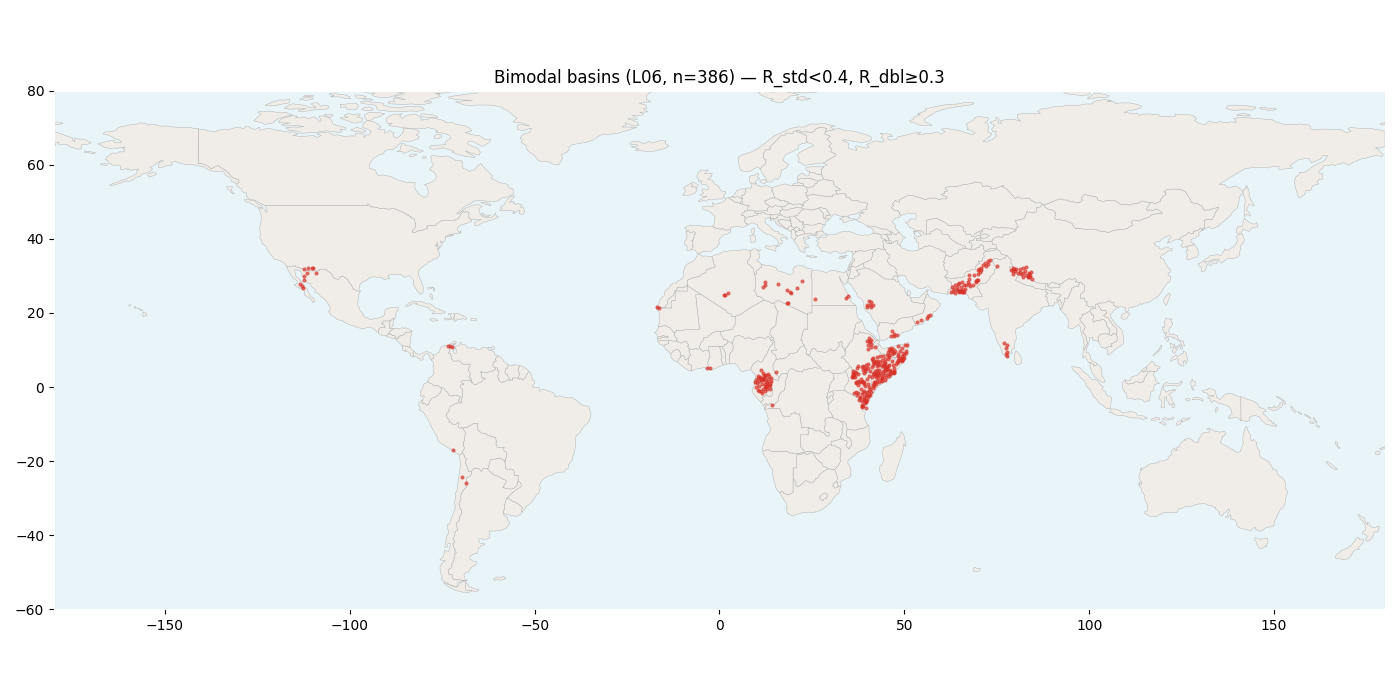

In [24]:
# Cell 10
# Quick global dot-map of bimodal basins.
# geopandas 1.1+ dropped gpd.datasets; naturalearth_lowres lives in pyogrio test fixtures.

import pyogrio
world_shp = Path(pyogrio.__file__).parent / 'tests' / 'fixtures' / 'naturalearth_lowres' / 'naturalearth_lowres.shp'
world = gpd.read_file(world_shp)

print("drawing bimodal basin map...")
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white'); ax.set_facecolor('#e8f4f8')
world.plot(ax=ax, color='#f0ede8', edgecolor='#aaaaaa', linewidth=0.3)
ax.scatter(centroids['lon'], centroids['lat'], s=4, color='#d73027', alpha=0.6)
ax.set_xlim(-180, 180); ax.set_ylim(-60, 80)
ax.set_title(f'Bimodal basins (L06, n={len(bimodal_ids):,}) — R_std<{THRESH_STD}, R_dbl≥{THRESH_DBL}', color='black')
ax.tick_params(colors='black')
plt.tight_layout()
outpath = OUT / 'wo2_bimodal_map.png'
fig.savefig(outpath, facecolor='white'); plt.close(fig)
from IPython.display import Image as IPImage
display(IPImage(str(outpath)))

In [25]:
# Cell 11
# Deep-dive on Mombasa: compute all derived scalars from monthly values and check
# whether pre_peak_month = circular-mean direction or argmax of monthly values.
# Also compute seas_phase_offset to show how temperature pulls the phase angle.

mombasa_sql = """
SELECT b.hybas_id, b.pre_mm_syr, b.tmp_dc_syr,
       b.pre_mm_s01, b.pre_mm_s02, b.pre_mm_s03, b.pre_mm_s04,
       b.pre_mm_s05, b.pre_mm_s06, b.pre_mm_s07, b.pre_mm_s08,
       b.pre_mm_s09, b.pre_mm_s10, b.pre_mm_s11, b.pre_mm_s12,
       b.tmp_dc_s01, b.tmp_dc_s02, b.tmp_dc_s03, b.tmp_dc_s04,
       b.tmp_dc_s05, b.tmp_dc_s06, b.tmp_dc_s07, b.tmp_dc_s08,
       b.tmp_dc_s09, b.tmp_dc_s10, b.tmp_dc_s11, b.tmp_dc_s12
FROM gaz.wh_cities c
JOIN basin08 b ON b.id = c.basin_id
WHERE c.city = 'Mombasa'
"""
mombasa = pd.read_sql(mombasa_sql, conn).iloc[0]

pre_vals = mombasa[[f'pre_mm_s{i:02d}' for i in range(1,13)]].values.astype(float)
tmp_vals = mombasa[[f'tmp_dc_s{i:02d}' for i in range(1,13)]].values.astype(float) / 10  # stored ×10

R_std, phi_std, R_dbl, phi_dbl = circular_stats(pre_vals)

# Replicate seasonality.py _compute_derived for seas_phase_offset
months = np.arange(12)
theta = 2 * np.pi * months / 12
tmp_shifted = tmp_vals - tmp_vals.min()
tmp_total = tmp_shifted.sum()
tmp_angle = np.arctan2(
    np.sum(tmp_shifted * np.sin(theta)) / tmp_total,
    np.sum(tmp_shifted * np.cos(theta)) / tmp_total
)
pre_total = pre_vals.sum()
pre_angle = np.arctan2(
    np.sum(pre_vals * np.sin(theta)) / pre_total,
    np.sum(pre_vals * np.cos(theta)) / pre_total
)
delta = abs(pre_angle - tmp_angle)
seas_phase_offset = min(delta, 2*np.pi - delta) / (2*np.pi) * 12

print(f"R_std  (= pre_concentration):    {R_std:.3f}")
print(f"R_dbl  (bimodal concentration):  {R_dbl:.3f}")
print(f"phi_std peak month (circ-mean):  {phi_std:.1f}  (0=Jan)")
print(f"argmax month (0-indexed):        {int(np.argmax(pre_vals))}  ({['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][int(np.argmax(pre_vals))]})")
print(f"seas_phase_offset (computed):    {seas_phase_offset:.2f}")
print()
print("Monthly precip (mm):")
for i, v in enumerate(pre_vals):
    print(f"  {['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][i]:3s}: {v:6.0f}")
print()
print("Monthly temp (°C):")
for i, v in enumerate(tmp_vals):
    print(f"  {['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][i]:3s}: {v:5.1f}")

R_std  (= pre_concentration):    0.215
R_dbl  (bimodal concentration):  0.341
phi_std peak month (circ-mean):  4.8  (0=Jan)
argmax month (0-indexed):        4  (May)
seas_phase_offset (computed):    4.08

Monthly precip (mm):
  Jan:     27
  Feb:     18
  Mar:     59
  Apr:    163
  May:    235
  Jun:     95
  Jul:     74
  Aug:     74
  Sep:     73
  Oct:    110
  Nov:    112
  Dec:     61

Monthly temp (°C):
  Jan:  26.5
  Feb:  26.9
  Mar:  27.4
  Apr:  26.6
  May:  25.0
  Jun:  24.1
  Jul:  23.3
  Aug:  23.4
  Sep:  24.0
  Oct:  25.1
  Nov:  25.9
  Dec:  26.4


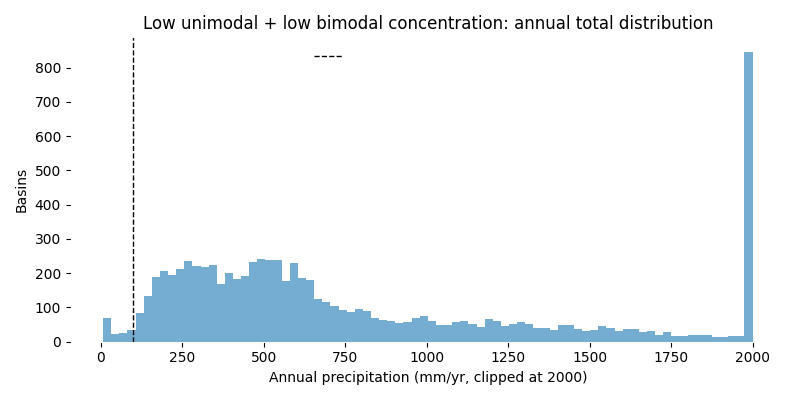

In [26]:
# Cell 12
# Part B prep: examine the arid vs bimodal boundary.
# Do low-R_std, low-R_dbl basins cleanly separate by annual total?
# Look at the distribution of pre_mm_syr for the aseasonal+arid group.

low_both = df06[(df06['R_std'] < THRESH_STD) & (df06['R_dbl'] < THRESH_DBL)].copy()
print(f"{len(low_both):,} basins with both concentrations below threshold")

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
ax.hist(low_both['pre_mm_syr'].clip(upper=2000), bins=80, color='#74add1', edgecolor='none')
ax.axvline(THRESH_ARID, color='black', lw=1, ls='--', label=f'arid threshold ({THRESH_ARID} mm/yr)')
ax.set_xlabel('Annual precipitation (mm/yr, clipped at 2000)', color='black')
ax.set_ylabel('Basins', color='black')
ax.tick_params(colors='black')
ax.legend(frameon=False)
ax.set_title('Low unimodal + low bimodal concentration: annual total distribution', color='black')
plt.tight_layout()
outpath = OUT / 'wo2_arid_aseasonal_hist.png'
fig.savefig(outpath, facecolor='white'); plt.close(fig)
display(IPImage(str(outpath)))